#DOG vs CAT Classification

Extracting Dataset using Kaggle API

In [1]:
# installing the Kaggle library
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing the Dog vs Cat Dataset from Kaggle

In [3]:
# Kaggle api
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:10<00:00, 78.2MB/s]



In [4]:
!ls

dogs-vs-cats.zip  kaggle.json  sample_data


In [5]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [6]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/train.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [7]:
import os
# counting the number of files in train folder
path, dirs, files = next(os.walk('/content/train'))
file_count = len(files)
print('Number of images: ', file_count)

Number of images:  25000


Printing the name of images

In [8]:
file_names = os.listdir('/content/train/')
print(file_names)

['dog.1735.jpg', 'cat.8448.jpg', 'cat.469.jpg', 'cat.9845.jpg', 'cat.8391.jpg', 'dog.7563.jpg', 'cat.8875.jpg', 'dog.2983.jpg', 'dog.3922.jpg', 'cat.9009.jpg', 'dog.10537.jpg', 'cat.9041.jpg', 'cat.9225.jpg', 'cat.5093.jpg', 'cat.5491.jpg', 'cat.2245.jpg', 'dog.5817.jpg', 'dog.8030.jpg', 'dog.3559.jpg', 'cat.6910.jpg', 'dog.4768.jpg', 'dog.11376.jpg', 'dog.5030.jpg', 'dog.10258.jpg', 'dog.11463.jpg', 'dog.5947.jpg', 'dog.10104.jpg', 'cat.3531.jpg', 'dog.8901.jpg', 'dog.8965.jpg', 'dog.7511.jpg', 'dog.6079.jpg', 'cat.12446.jpg', 'dog.3308.jpg', 'dog.2394.jpg', 'cat.8783.jpg', 'cat.11271.jpg', 'dog.12097.jpg', 'dog.2443.jpg', 'dog.7786.jpg', 'cat.11204.jpg', 'cat.5060.jpg', 'dog.4260.jpg', 'cat.8786.jpg', 'dog.141.jpg', 'dog.11010.jpg', 'dog.9302.jpg', 'dog.8640.jpg', 'cat.3676.jpg', 'cat.2847.jpg', 'dog.7453.jpg', 'cat.11671.jpg', 'cat.5865.jpg', 'dog.4738.jpg', 'dog.7350.jpg', 'cat.4858.jpg', 'cat.8713.jpg', 'dog.9898.jpg', 'dog.5630.jpg', 'cat.2693.jpg', 'cat.3950.jpg', 'dog.2502.jpg'

Importing the Dependencies

In [9]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

Displaying the images of dogs and cats

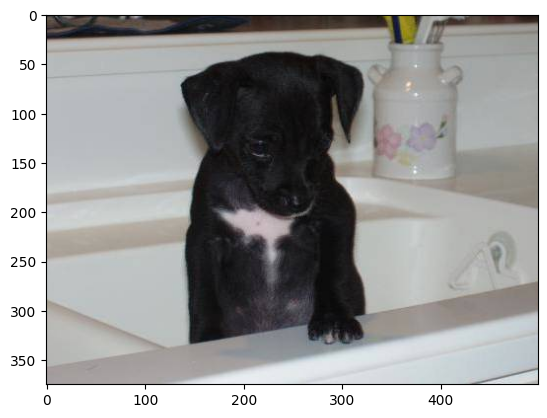

In [10]:
# display dog image
img = mpimg.imread('/content/train/dog.8298.jpg')
imgplt = plt.imshow(img)
plt.show()

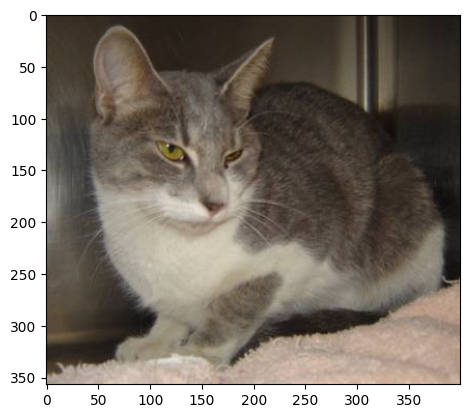

In [11]:
# display cat image
img = mpimg.imread('/content/train/cat.4352.jpg')
imgplt = plt.imshow(img)
plt.show()

In [12]:
file_names = os.listdir('/content/train/')

for i in range(5):

  name = file_names[i]
  print(name[0:3])



dog
cat
cat
cat
cat


In [13]:
file_names = os.listdir('/content/train/')

dog_count = 0
cat_count = 0

for img_file in file_names:

  name = img_file[0:3]

  if name == 'dog':
    dog_count += 1

  else:
    cat_count += 1

print('Number of dog images =', dog_count)
print('Number of cat images =', cat_count)

Number of dog images = 12500
Number of cat images = 12500


Resizing all the images

In [14]:
#creating a directory for resized images
os.mkdir('/content/image resized')

In [17]:
import os
from PIL import Image

original_folder = '/content/train/'
resized_folder = '/content/image resized/'

all_files = os.listdir(original_folder)  # call once

cat_files = [f for f in all_files if f.startswith('cat')]
dog_files = [f for f in all_files if f.startswith('dog')]

n = 1000  # 1000 cats + 1000 dogs = 2000 total
selected_files = cat_files[:n] + dog_files[:n]

for filename in selected_files:
    img_path = original_folder + filename
    img = Image.open(img_path)
    img = img.resize((224, 224))
    img = img.convert('RGB')

    newImgPath = resized_folder + filename
    img.save(newImgPath)

print(len(selected_files))

2000


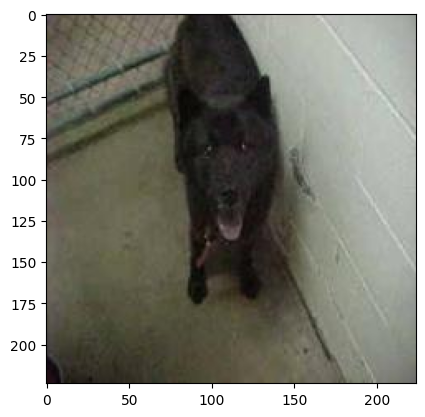

In [20]:
# display resized dog image
img = mpimg.imread('/content/image resized/dog.3922.jpg')
imgplt = plt.imshow(img)
plt.show()

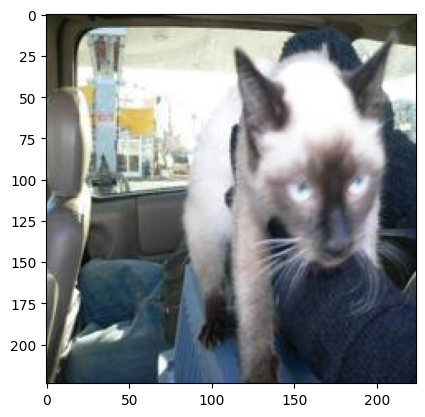

In [25]:
# display resized cat image
img = mpimg.imread('/content/image resized/cat.9845.jpg')
imgplt = plt.imshow(img)
plt.show()

**Creating labels for resized images of dogs and cats**

Cat --> 0

Dog --> 1

In [27]:
# creating labels
filenames = os.listdir('/content/image resized/')

labels = []

for file_name in filenames:
    label = file_name[0:3]
    labels.append(1 if label == 'dog' else 0)

print(len(labels))

2031


In [28]:
print(filenames[0:5])
print(len(filenames))

['dog.1735.jpg', 'cat.8448.jpg', 'cat.469.jpg', 'cat.9845.jpg', 'cat.8391.jpg']
2031


In [29]:
print(labels[0:5])
print(len(labels))

[1, 0, 0, 0, 0]
2031


In [30]:
# counting the images of dogs and cats out of 2000 images
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[1031 1000]


Converting all the resized images to numpy arrays

In [31]:
import cv2
import glob

In [32]:
image_directory = '/content/image resized/'
image_extension = ['png', 'jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [33]:
print(dog_cat_images)

[[[[207 215 214]
   [210 218 217]
   [217 225 224]
   ...
   [255 252 253]
   [255 252 253]
   [255 252 253]]

  [[210 216 215]
   [205 213 212]
   [203 209 208]
   ...
   [255 254 255]
   [255 254 255]
   [255 254 255]]

  [[206 211 210]
   [205 211 210]
   [206 211 210]
   ...
   [255 254 255]
   [255 254 255]
   [255 254 255]]

  ...

  [[194 182 180]
   [201 189 187]
   [204 192 190]
   ...
   [167 137 120]
   [167 137 120]
   [167 137 120]]

  [[202 190 188]
   [208 196 194]
   [211 199 197]
   ...
   [167 137 120]
   [166 136 119]
   [166 136 119]]

  [[204 192 190]
   [201 189 187]
   [196 184 182]
   ...
   [164 134 117]
   [164 134 117]
   [163 133 116]]]


 [[[ 86  90 101]
   [ 93  97 108]
   [ 82  88  99]
   ...
   [184 192 199]
   [183 191 198]
   [182 190 197]]

  [[ 87  91 102]
   [ 92  96 107]
   [ 77  83  94]
   ...
   [184 192 199]
   [183 191 198]
   [182 190 197]]

  [[ 88  92 103]
   [ 89  93 104]
   [ 68  74  85]
   ...
   [184 192 199]
   [183 191 198]
   [182 190

In [34]:
type(dog_cat_images)

numpy.ndarray

In [35]:
print(dog_cat_images.shape)

(2031, 224, 224, 3)


In [36]:
X = dog_cat_images
Y = np.asarray(labels)

**Train Test Split**

In [37]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [38]:
print(X.shape, X_train.shape, X_test.shape)

(2031, 224, 224, 3) (1624, 224, 224, 3) (407, 224, 224, 3)


1600 --> training images

400 --> test images

In [39]:
# scaling the data
X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [40]:
print(X_train_scaled)

[[[[0.6627451  0.87843137 0.90588235]
   [0.6627451  0.87843137 0.90588235]
   [0.66666667 0.87843137 0.90588235]
   ...
   [0.58039216 0.79607843 0.82352941]
   [0.58039216 0.79607843 0.82352941]
   [0.58039216 0.79607843 0.82352941]]

  [[0.6627451  0.87843137 0.90588235]
   [0.6627451  0.87843137 0.90588235]
   [0.66666667 0.87843137 0.90588235]
   ...
   [0.58039216 0.79607843 0.82352941]
   [0.58039216 0.79607843 0.82352941]
   [0.58039216 0.79607843 0.82352941]]

  [[0.6627451  0.87843137 0.90588235]
   [0.6627451  0.87843137 0.90588235]
   [0.66666667 0.87843137 0.90588235]
   ...
   [0.58039216 0.79607843 0.82352941]
   [0.58039216 0.79607843 0.82352941]
   [0.58039216 0.79607843 0.82352941]]

  ...

  [[0.48627451 0.58039216 0.69019608]
   [0.44705882 0.54117647 0.65098039]
   [0.41568627 0.50980392 0.61960784]
   ...
   [0.15294118 0.2627451  0.38039216]
   [0.17647059 0.28627451 0.40392157]
   [0.18431373 0.29411765 0.41176471]]

  [[0.5372549  0.62352941 0.73333333]
   [0.4

**Building the Neural Network**

In [41]:
import tensorflow as tf
import tensorflow_hub as hub

In [44]:
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
pretrained_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [45]:
num_of_classes = 2

model = tf.keras.Sequential([

    pretrained_model,
    tf.keras.layers.Dense(num_of_classes)

])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [46]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['acc']
)

In [47]:
model.fit(X_train_scaled, Y_train, epochs=5)

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - acc: 0.9015 - loss: 0.2258
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - acc: 0.9723 - loss: 0.0898
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - acc: 0.9748 - loss: 0.0726
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - acc: 0.9846 - loss: 0.0573
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - acc: 0.9865 - loss: 0.0496


In [48]:
score, acc = model.evaluate(X_test_scaled, Y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - acc: 0.9803 - loss: 0.0787
Test Loss = 0.07866171002388
Test Accuracy = 0.9803439974784851


**Predictive System**

Path of the image to be predicted: /content/dog2.jpg


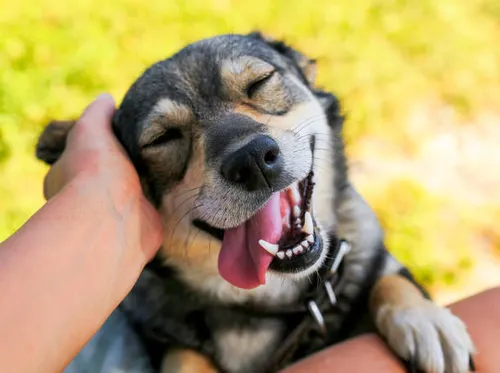

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
[[-1.6667813  2.902762 ]]
1
The image represents a Dog


In [54]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')

Path of the image to be predicted: /content/cat2.jpg


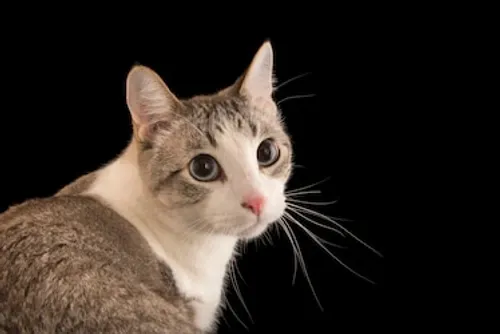

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
[[ 4.4111776 -4.3270574]]
0
The image represents a Cat


In [55]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')

In [56]:
98

98